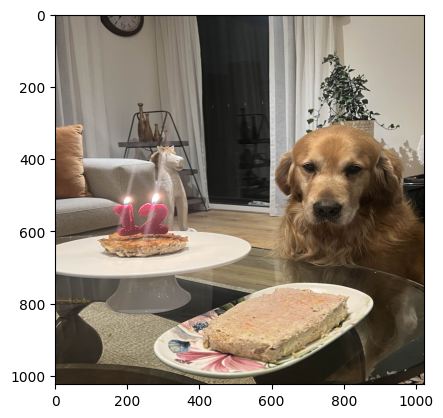

In [7]:
from torchvision.models.detection import retinanet_resnet50_fpn_v2
import torch as t
from torchvision.transforms.functional import convert_image_dtype
import cv2
import matplotlib.pyplot as plt

winter = cv2.imread('test.jpg', cv2.IMREAD_COLOR_RGB)
winter = cv2.resize(winter, (1024, 1024))

plt.imshow(winter)
plt.show()


In [8]:
winter_int = t.from_numpy(winter).permute(2, 0, 1)

In [9]:
batch = convert_image_dtype(winter_int, dtype=t.float)

In [22]:
model = retinanet_resnet50_fpn_v2(pretrained=True)
model = model.eval()

/mnt/c/Users/n3/Desktop/od-eval/.linuxvnev/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/c/Users/n3/Desktop/od-eval/.linuxvnev/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_V2_Weights.COCO_V1`. You can also use `weights=RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_v2_coco-5905b1c5.pth" to /home/rafa/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_v2_coco-5905b1c5.pth


100%|██████████| 146M/146M [00:24<00:00, 6.14MB/s] 


In [28]:
res = model([batch])

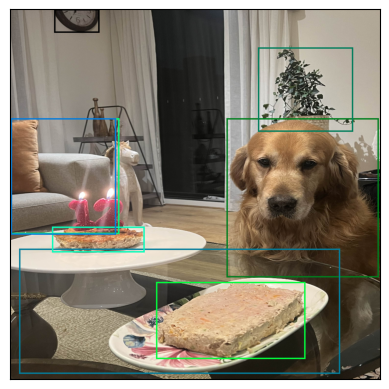

In [31]:
from torchvision.utils import draw_bounding_boxes
import torchvision.transforms.functional as TF

def show(imgs):
    import numpy as np
    if not isinstance(imgs, list):
        imgs = [imgs]
    fix, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = TF.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

show(
    draw_bounding_boxes(winter_int, boxes=res[0]['boxes'][res[0]['scores'] > 0.5], width=4)
)